In [31]:
import torch
import pandas as pd
import networkx as nx
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import numpy as np
from Model import ModelInterface
from tqdm import tqdm


def make_dataset_graph_model(nodes_df:pd.DataFrame, edges_df:pd.DataFrame):
    nodes_df['GO_embeddings'] = nodes_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
    nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.float))

    # Aggiungo nodi al grafo
    G = nx.Graph()
    for _, row in nodes_df.iterrows():
        num_id = int(row['num_id'])
        G.add_node(num_id, name=row['STRING_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))

    edges_df['num_id_1'] = edges_df['num_id_1'].astype(int)
    edges_df['num_id_2'] = edges_df['num_id_2'].astype(int)
    edges = torch.tensor(edges_df[['num_id_1', 'num_id_2']].values.T, dtype=torch.long)

    # Per visualizzazione debug
    G.add_edges_from(zip(edges_df['num_id_1'], edges_df['num_id_2']))

    data = Data(
        x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
        edge_index=edges,  # Edge list
        y=torch.stack([G.nodes[n]['y'] for n in G.nodes]),
        name= [G.nodes[n]['name'] for n in G.nodes]
    )

    # Escludendo le proteine in comune estrai un 10% per testing finale
    common_proteins_mask = np.array(["_AD" in name or "_PD" in name for name in data.name])
    non_common_indices = np.where(~common_proteins_mask)[0]

    num_test = int(0.1 * len(non_common_indices))
    final_test_indices = np.random.choice(non_common_indices, size=num_test, replace=False)
    final_test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    final_test_mask[final_test_indices] = True

    data.final_test_mask = final_test_mask
    data.kfold_usable_mask = ~(final_test_mask)

    return data, G

def make_dataset_traditional_model(nodes_df:pd.DataFrame, features='GO_embeddings'):
    nodes_df[features] = nodes_df[features].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
    nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.int))

    common_nodes = set(nodes_df[nodes_df['label'] == 2]['STRING_id'].to_list())
    nodes_df = nodes_df[~nodes_df['STRING_id'].isin(common_nodes)]

    G = nx.Graph()
    for _, row in nodes_df.iterrows():
        G.add_node(row['id'], x=row[features], y=torch.tensor(row['label'], dtype=torch.long))

    data = Data(
        x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
        y=torch.stack([G.nodes[n]['y'] for n in G.nodes])
    )

    return data, G

def train_multiple_times(Model: type[ModelInterface], num_iterations: int, data, lr=0.001, 
                         hidden_channels=64, out_channels=1, k_folds=5, epochs_per_fold=50):
    
    best_metrics_list = []

    with tqdm(total=num_iterations, desc="Training Progress", unit="iteration") as pbar:
        for _ in range(num_iterations):
            model = Model(in_channels=data.x.shape[1], hidden_channels=hidden_channels, out_channels=out_channels, dropout=0)

            _, best_metrics = model.k_fold_cross_validation(data, k=k_folds, epochs=epochs_per_fold, learning_rate=lr, patience=10)
            best_metrics_list.append(best_metrics)
            pbar.update(1)

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    avg_metrics = {}
    std_metrics = {}
    for m in metrics:
        avg_metrics[m] = np.mean([metric[m] for metric in best_metrics_list], dtype='float64')
        std_metrics[m] = np.std([metric[m] for metric in best_metrics_list], dtype='float64')

    return avg_metrics, std_metrics

def train_svm(file_path, n_iterations):
    from sklearn.model_selection import train_test_split
    from sklearn.utils import resample
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

    df = pd.read_csv(file_path)

    import ast
    df["GO_embeddings"] = df["GO_embeddings"].apply(ast.literal_eval)

    embeddings_df = pd.DataFrame(df["GO_embeddings"].tolist())

    X = embeddings_df
    y = df["label"]

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

    accuracy_train_scores = []
    accuracy_val_scores = []
    accuracy_test_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    with tqdm(total=n_iterations, desc="Training Progress", unit="iteration") as pbar:
        for _ in range(n_iterations):
            # Bootstrapping
            X_boot, y_boot = resample(X_train, y_train, replace=True)
            
            svm_model_boot = SVC(kernel="rbf", C=10, gamma=0.001, class_weight="balanced")
            svm_model_boot.fit(X_boot, y_boot)
            
            train_acc = svm_model_boot.score(X_boot, y_boot)
            accuracy_train_scores.append(train_acc)
            val_acc = svm_model_boot.score(X_val, y_val)
            accuracy_val_scores.append(val_acc)

            y_pred = svm_model_boot.predict(X_test)

            accuracy_test_scores.append(accuracy_score(y_test, y_pred))
            precision_scores.append(precision_score(y_test, y_pred, average="weighted", zero_division=0))
            recall_scores.append(recall_score(y_test, y_pred, average="weighted", zero_division=0))
            f1_scores.append(f1_score(y_test, y_pred, average="weighted", zero_division=0))

            pbar.update(1)

    best_metrics_list = {
        'Accuracy': accuracy_test_scores,
        'Precision': precision_scores,
        'Recall': recall_scores,
        'F1-Score': f1_scores
    }
    
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    avg_metrics = {}
    std_metrics = {}
    for m in metrics:
        avg_metrics[m] = np.mean(best_metrics_list[m], dtype='float64')
        std_metrics[m] = np.std(best_metrics_list[m], dtype='float64')

    return avg_metrics, std_metrics

In [ ]:
from MLP import MLP
from GraphSAGE import GCN_Sage
from GCN import GCN

mlp_emb_data, _ = make_dataset_traditional_model(
    pd.read_csv('../pre_processing_output/classification_three_labels_nodes_main_components.csv'))

mlp_sim_data, _ = make_dataset_traditional_model(
    pd.read_csv('../pre_processing_output/classification_three_labels_nodes_sim_main_components.csv'),
    features='features')

graph_nodes_emb_df = pd.read_csv("../pre_processing_output/duplicated_nodes_main_components.csv")

graph_nodes_sim_df = pd.read_csv("../pre_processing_output/duplicated_nodes_main_components_sim.csv")
graph_edges_df = pd.read_csv("../pre_processing_output/duplicated_edges_main_components.csv")
graph_edges_df2 = graph_edges_df.copy()

graph_emb_data, _ = make_dataset_graph_model(graph_nodes_emb_df, graph_edges_df)
graph_sim_data, _ = make_dataset_graph_model(graph_nodes_sim_df, graph_edges_df2)

training_schedule = {
    "GCN - emb": (GCN, graph_emb_data),
    "GCN - sim": (GCN, graph_sim_data),
    "GraphSAGE - emb": (GCN_Sage, graph_emb_data),
    "GraphSAGE - sim": (GCN_Sage, graph_sim_data),
    "MLP - emb": (MLP, mlp_emb_data),
    "MLP - sim": (MLP, mlp_sim_data),
}

results = dict()
std_devs = dict()
for title, to_train in training_schedule.items():
    print(title)
    performances, std_dev = train_multiple_times(to_train[0], 100, to_train[1])
    results[title] = performances
    std_devs[title] = std_dev

print('SVM - emb')
results["SVM - emb"], std_devs["SVM - emb"] = train_svm("../pre_processing_output/duplicated_nodes_main_components.csv", 100)
print('SVM - sim')
results["SVM - sim"], std_devs["SVM - sim"] = train_svm("../pre_processing_output/duplicated_nodes_main_components_sim.csv", 100)

results_df = pd.DataFrame.from_dict(results, orient='index')
std_dev_df = pd.DataFrame.from_dict(std_devs, orient='index')

/tmp/ipykernel_26745/561657854.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(row['id'], x=row[features], y=torch.tensor(row['label'], dtype=torch.long))
/tmp/ipykernel_26745/561657854.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(row['id'], x=row[features], y=torch.tensor(row['label'], dtype=torch.long))
/tmp/ipykernel_26745/561657854.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(num_id, name=row['STRING_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))
/tm

GCN - emb


Training Progress: 100%|██████████| 10/10 [00:16<00:00,  1.68s/iteration]


GCN - sim


Training Progress: 100%|██████████| 10/10 [00:11<00:00,  1.17s/iteration]


...

Training Progress: 100%|██████████| 10/10 [00:03<00:00,  2.87iteration/s]


SVM - emb


Training Progress: 100%|██████████| 100/100 [00:01<00:00, 67.72iteration/s]


SVM - sim


Training Progress: 100%|██████████| 100/100 [00:01<00:00, 67.80iteration/s]


{'Accuracy': {'GCN - emb': 0.984153846153846, 'GCN - sim': 0.8586153846153847, 'GraphSAGE - emb': 0.9521538461538462, 'GraphSAGE - sim': 0.8423076923076923, 'MLP - emb': 0.925, 'MLP - sim': 0.875, 'SVM - emb': 0.5958823529411764, 'SVM - sim': 0.7617647058823529}, 'Precision': {'GCN - emb': 0.9714285714285715, 'GCN - sim': 0.9018964368964368, 'GraphSAGE - emb': 0.9393452380952381, 'GraphSAGE - sim': 0.8579374791874791, 'MLP - emb': 0.9289148351648352, 'MLP - sim': 0.9437957875457876, 'SVM - emb': 0.6020876411170528, 'SVM - sim': 0.8021224853577796}, 'Recall': {'GCN - emb': 1.0, 'GCN - sim': 0.8153846153846154, 'GraphSAGE - emb': 0.976923076923077, 'GraphSAGE - sim': 0.8461538461538461, 'MLP - emb': 0.930952380952381, 'MLP - sim': 0.8176190476190476, 'SVM - emb': 0.5958823529411764, 'SVM - sim': 0.7617647058823529}, 'F1-Score': {'GCN - emb': 0.9851851851851853, 'GCN - sim': 0.85393893224328, 'GraphSAGE - emb': 0.9559937967524172, 'GraphSAGE - sim': 0.846561813665262, 'MLP - emb': 0.92803

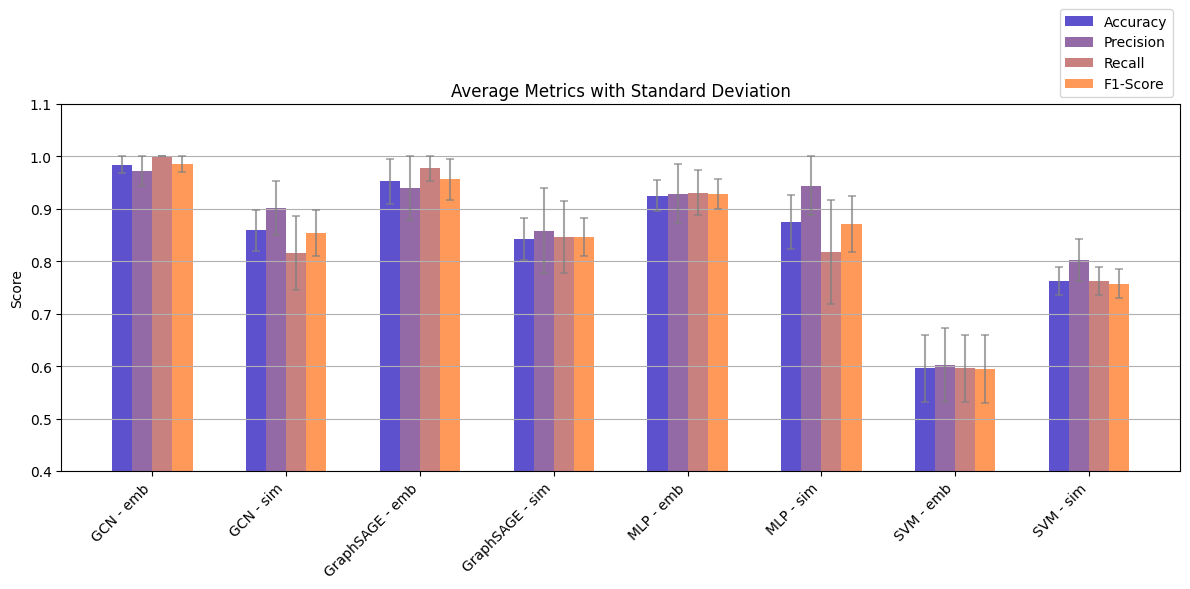

In [35]:
import matplotlib.colors as mcolors

def get_color_gradient(start_hex, end_hex, n):
    cmap = mcolors.LinearSegmentedColormap.from_list("grad", [start_hex, end_hex])
    return [mcolors.to_hex(cmap(i / (n - 1))) for i in range(n)]

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.15
x = np.arange(len(results_df))

colors = get_color_gradient("#5D51CD", "#FF9959", 4)

error_kw = {
    "ecolor": "gray",     
    "elinewidth": 1.5,    
    "capsize": 3,        
    "capthick": 1.2,      
    "alpha": 0.7
}

for i, metric in enumerate(results_df.columns):
    values = results_df[metric].values
    errors = std_dev_df[metric].values

    error_upper_bound = np.minimum(values + errors, 1.0) - values

    ax.bar(
        x + i * bar_width,
        values,
        bar_width,
        label=metric,
        yerr=error_upper_bound,
        error_kw=error_kw,
        capsize=5,  # lunghezza delle "alette" delle barre di errore
        color=colors[i]
    )

print(results_df.to_dict())
print(std_dev_df.to_dict())

ax.set_xticks(x + bar_width * (len(results_df.columns) - 1) / 2)
ax.set_xticklabels(results_df.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel("Score")
ax.set_title("Average Metrics with Standard Deviation")
ax.set_ylim(0.4, 1.1)
ax.legend(loc='lower right', bbox_to_anchor=(1, 1))
ax.grid(axis='y')
plt.tight_layout()
plt.show()
